In [54]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Class +1
X1 = np.random.randn(50, 2) + np.array([2, 2])

# Class -1
X2 = np.random.randn(50, 2) + np.array([-2, -2])

X = np.vstack((X1, X2))
y = np.hstack((np.ones(50), -np.ones(50)))

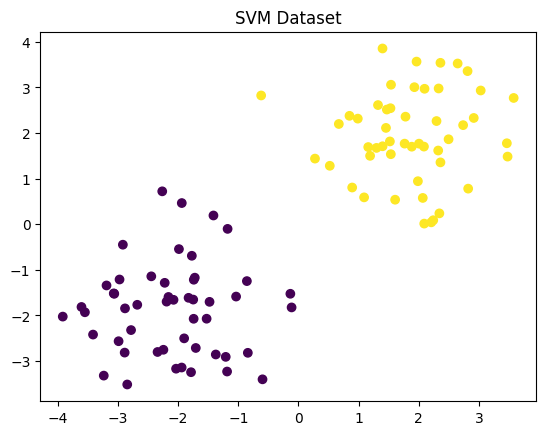

In [55]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("SVM Dataset")
plt.show()

In [85]:
w = np.zeros(X.shape[1])
b = 0

learning_rate = 0.001
lambda_param = 0.1  # regularization strength
epochs = 1000

In [86]:
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

In [87]:
for _ in range(epochs):
    
    # Compute condition for all points
    condition = y * (X @ w + b)
    
    # Find violating points (inside margin or misclassified)
    mask = condition < 1
    
    # Gradient for w
    dw = 2 * lambda_param * w
    if np.any(mask):
        dw -= np.sum((y[mask][:, None] * X[mask]), axis=0)
    
    # Gradient for b
    db = 0
    if np.any(mask):
        db = np.sum(y[mask])
    
    # Update parameters
    w -= learning_rate * dw
    b += learning_rate * db

In [88]:
x_vals = np.linspace(-5, 5, 100)

In [89]:
def get_line(x, w, b, offset=0):
    return (-(w[0] * x + b) + offset) / w[1]

y_vals = get_line(x_vals, w, b)
y_margin_pos = get_line(x_vals, w, b, offset=1)
y_margin_neg = get_line(x_vals, w, b, offset=-1)

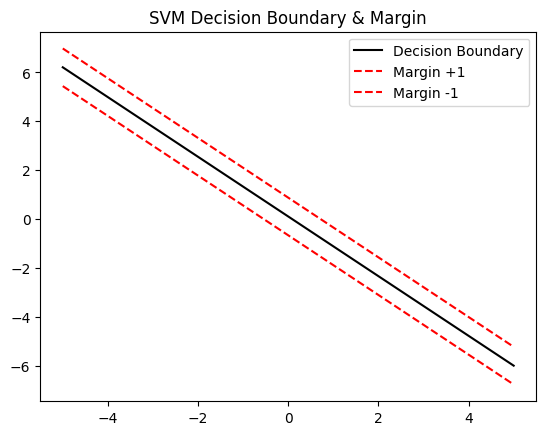

In [90]:
plt.plot(x_vals, y_vals, 'k-', label='Decision Boundary')
plt.plot(x_vals, y_margin_pos, 'r--', label='Margin +1')
plt.plot(x_vals, y_margin_neg, 'r--', label='Margin -1')

plt.legend()
plt.title("SVM Decision Boundary & Margin")
plt.show()

In [91]:
print("w:", w)
print("b:", b)

w: [1.58534325 1.2995171 ]
b: -0.1400000000000001


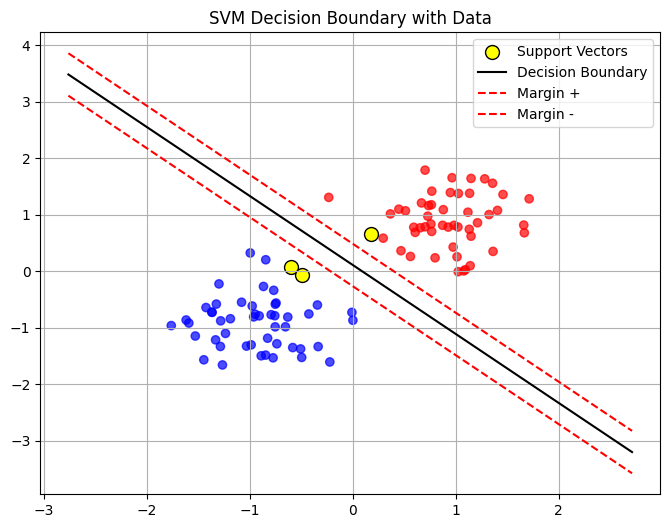

In [92]:
plt.figure(figsize=(8,6))

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)

# Create x values
x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)

# Line function
def get_line(x, w, b, offset=0):
    return (-(w[0] * x + b) + offset) / w[1]

# Decision boundary
y_vals = get_line(x_vals, w, b)

# Proper margin using ||w||
margin = 1 / np.linalg.norm(w)

y_margin_pos = get_line(x_vals, w, b, offset=margin)
y_margin_neg = get_line(x_vals, w, b, offset=-margin)


condition = y * (X @ w + b)
support_vectors = X[np.abs(condition - 1) < 0.05]
plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
            color='yellow', edgecolors='black', s=100, label='Support Vectors')

# Plot lines
plt.plot(x_vals, y_vals, 'k-', label='Decision Boundary')
plt.plot(x_vals, y_margin_pos, 'r--', label='Margin +')
plt.plot(x_vals, y_margin_neg, 'r--', label='Margin -')

plt.title("SVM Decision Boundary with Data")
plt.legend()
plt.grid(True)

plt.show()